Root growth is one of the most important and difficult components of crop models. Compared to the large number of observations and models available for aboveground plant growth, information about root growth along the soil profile is fairly limited. Yet, estimates of rooting depth are essential to compute the soil water and nutrient balance, since roots determine the volume of soil from which the crop can extract water.

Simple root growth models estimate the bulk extent of the root zone in one dimension (depth), while more sophisticated models can represent branching patterns, root architecture, and properties of the growing medium. In this exercise we will implement the simple model used in the AquaCrop model (Eq. 12 in Steduto et al., 2009), in which rooting depth is a function of thermal time (also known as growing degree days).

## Model

$$ Z = Z_o + (Z_x - Z_o) \Bigg( \frac{TT-\frac{1}{2}TT_o}{TT_x-\frac{1}{2}TT_o} \Bigg)^{1/n}$$

$Z$ is the rooting depth (cm) at thermal time $TT$<br>
$Z_o$ is the initial rooting depth, approximately the sowing depth (cm)<br>
$Z_x$ is the maximum rooting depth (cm)<br>
$TT$ is the cumulative thermal time since planting (°C d)<br>
$TT_o$ is the thermal time from planting to emergence (°C d)<br>
$TT_x$ is the thermal time from planting until the maximum rooting depth is reached (°C d)<br>
$n$ is a shape factor of the root growth curve. Values of $n$ greater than 1 produce fast root growth early in the season that slows down as roots approach the maximum depth.<br>

## Model assumptions

- Root growth only depends on temperature. This is a simplification, since soil moisture, soil nutrients, and soil penetration resistance also exert an important control on root growth.

- Root growth starts halfway (in terms of thermal time) between planting and emergence. This is about right since the first seminal roots appear before the coleoptile or cotyledons emerge above the soil surface.

In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Data

We will use daily air temperature observations from the Gypsum, KS station of the Kansas Mesonet during 2018.

In [2]:
# Read dataset
df = pd.read_csv('../datasets/gypsum_2018_daily.csv')
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], format='%Y-%m-%d')
df[['TIMESTAMP','TEMP2MAVG','TEMP2MMIN','TEMP2MMAX']].head()


,TIMESTAMP,TEMP2MAVG,TEMP2MMIN,TEMP2MMAX
0,2018-01-01,-15.15,-19.56,-11.00
1,2018-01-02,-16.48,-22.10,-10.40
2,2018-01-03,-11.03,-20.64,-2.71
3,2018-01-04,-5.83,-11.79,0.24
4,2018-01-05,-4.73,-14.22,5.36


In [3]:
# Select the growing season
planting_date = pd.Timestamp('2018-04-15')
season_length = 120 # days

idx_season = (df['TIMESTAMP'] >= planting_date) & (df['TIMESTAMP'] < planting_date + pd.Timedelta(days=season_length))
df_season = df.loc[idx_season].reset_index(drop=True)
print('Number of days:', df_season.shape[0])


Number of days: 120


## Thermal time

Thermal time is computed as the cumulative sum of the daily mean air temperature above a base temperature, below which the crop does not grow.

In [4]:
# Compute daily and cumulative thermal time (degrees Celsius-day)
T_base = 10 # Base temperature for corn

df_season['TT'] = np.maximum(df_season['TEMP2MAVG'] - T_base, 0)
df_season['TT_cum'] = df_season['TT'].cumsum()
df_season[['TIMESTAMP','TEMP2MAVG','TT','TT_cum']].head()


,TIMESTAMP,TEMP2MAVG,TT,TT_cum
0,2018-04-15,-0.41,0.00,0.00
1,2018-04-16,-1.70,0.00,0.00
2,2018-04-17,4.45,0.00,0.00
3,2018-04-18,15.31,5.31,5.31
4,2018-04-19,8.35,0.00,5.31


## Define model

In [5]:
def root_depth(TT, Z_o, Z_x, TT_o, TT_x, n):
    """Function that computes rooting depth (cm) as a function of
    cumulative thermal time following the AquaCrop model (Steduto et al., 2009).

    Inputs:
    TT: Cumulative thermal time since planting (Celsius-day)
    Z_o: Initial rooting depth (cm)
    Z_x: Maximum rooting depth (cm)
    TT_o: Thermal time from planting to emergence (Celsius-day)
    TT_x: Thermal time from planting to maximum rooting depth (Celsius-day)
    n: Shape factor of the root growth curve
    """
    TT_start = TT_o / 2 # Roots start growing halfway between planting and emergence

    if TT <= TT_start:
        Z = Z_o
    elif TT >= TT_x:
        Z = Z_x
    else:
        Z = Z_o + (Z_x - Z_o) * ((TT - TT_start) / (TT_x - TT_start))**(1/n)

    return Z


In [6]:
# Model parameters (approximate values for corn)
Z_o = 5     # cm
Z_x = 150   # cm
TT_o = 100  # Celsius-day
TT_x = 1000 # Celsius-day
n = 1.5     # Shape factor

# Compute rooting depth for each day of the growing season
Z = []
for TT in df_season['TT_cum']:
    Z.append(root_depth(TT, Z_o, Z_x, TT_o, TT_x, n))

df_season['root_depth'] = Z


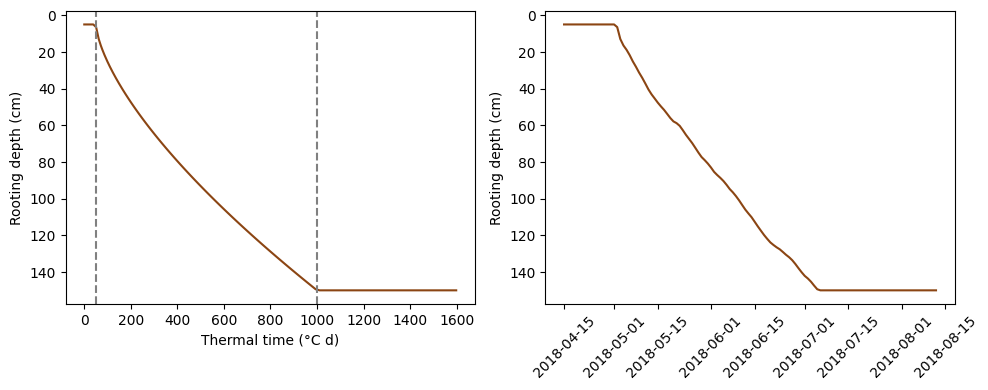

In [7]:
# Plot rooting depth as a function of thermal time and time
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(df_season['TT_cum'], df_season['root_depth'], color='saddlebrown')
plt.axvline(TT_o/2, color='gray', linestyle='--')
plt.axvline(TT_x, color='gray', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel('Thermal time (°C d)')
plt.ylabel('Rooting depth (cm)')

plt.subplot(1,2,2)
plt.plot(df_season['TIMESTAMP'], df_season['root_depth'], color='saddlebrown')
plt.gca().invert_yaxis()
plt.xticks(rotation=45)
plt.ylabel('Rooting depth (cm)')

plt.tight_layout()
plt.show()


In [8]:
# Find the date at which roots reach 1 m and the maximum rooting depth
idx_1m = df_season['root_depth'] >= 100
idx_max = df_season['root_depth'] >= Z_x

print('Roots reach 100 cm on', df_season.loc[idx_1m, 'TIMESTAMP'].iloc[0].date())
print(f'Roots reach the maximum depth of {Z_x} cm on', df_season.loc[idx_max, 'TIMESTAMP'].iloc[0].date())


Roots reach 100 cm on 2018-06-10
Roots reach the maximum depth of 150 cm on 2018-07-06


## Practice

- Run the model using shape factors of 1, 1.5, and 2 and plot all three curves in the same figure. How does the shape factor change the timing of root growth?

- Run the model for a planting date in early April and another one in late May. How many days does it take for roots to reach 1 m in each case?

- Combine this model with the soil water balance exercise by allowing the crop to extract water only from the soil layers reached by the roots.

## References

Steduto, P., Hsiao, T.C., Raes, D. and Fereres, E., 2009. AquaCrop—The FAO crop model to simulate yield response to water: I. Concepts and underlying principles. Agronomy Journal, 101(3), pp.426-437.